In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Definición de las funciones para obtener la función de costo, su gradiente y su hessiano.

In [2]:
def f_func(x):
    """Función f(x) = sum _{i=1}^{n} [i/10 * (e^{x_i} - x_i)] (experimento 1 del paper)
    Recibe:
    - x : una lista 

    Retorna:
    - f(x) : numpy array
    """
    x = np.array(x, dtype= np.float64)
    n = len(x)
    idx_arr = (np.arange(1, n+1) / 10.0)
    output = np.sum((idx_arr)*(np.exp(x) - x))
    return output


def grad_func(x):
    """Gradiente de f(x) = sum _{i=1}^{n} [i/10 * (e^{x_i} - x_i)] (experimento 1 del paper)
    Recibe:
    - x : una lista 
    Retorna:
    - grad_f(x) : numpy array"""

    x = np.array(x, dtype= np.float64)
    n = len(x)
    idx_arr = (np.arange(1, n+1) / 10.0)
    output = (idx_arr)*(np.exp(x) - 1)
    return output


def hessian_func(x):
    """Hessiana de f(x) = sum _{i=1}^{n} [i/10 * (e^{x_i} - x_i)] (experimento 1 del paper)
    Recibe:
    - x : una lista 
    Retorna:
    - hess_f(x) : numpy array"""

    x = np.array(x, dtype= np.float64)
    n = len(x)
    idx_arr = (np.arange(1, n+1) / 10.0)
    output = idx_arr * np.exp(x)
    return np.diag(output)


def Hk_gk_func(x):
    """Función que devuelve el resultado de Hk*gk
    Recibe:
    - Hk : numpy array con información de la Hessiana
    - gk : numpy array con el gradiente de la función en el punto xk
    Retorna:
    - Hk*gk : numpy array
    """
    Hk = hessian_func(x)
    gk = grad_func(x)
    return Hk*gk



   

# Función para generar una secuencia {$e_k$} tal que $\sum_{k=0}^{\infty} e_k < \infty$ (función utilizada en el paper)

In [3]:

def ek_func(k, gamma, t, alpha_k, gk_T_wk):
    """Función que devuelve el resultado de ek
    Recibe:
    - k : número de iteración
    - gamma : parámetro usado para el backtracking
    - t : parámetro requerido para el algoritmo de extended DWGM
    - alpha_k : paso de la iteración k
    - gk_T_wk : producto punto de gk y wk
    Retorna:
    - ek : escalar
    """

    if k == 0:
        k_pow2 = 1
    else:
        k_pow2 = k**2
    
    ek = min(1/k_pow2,0.9 * gamma * t * alpha_k * gk_T_wk)

    return ek

# Implementación de extended DWGM method

In [4]:
def extended_DWGM(f_func ,grad_func, hessian_func , ek_func , x0, t = 1 ,max_iter = 10000, epsilon = 1e-6,delta = 0.9 ,gamma = 1e-4, m = 100):
    
    """Implementación del algoritmo Extended DWGM del paper 'An extended delayed weighted gradient algorithm for solving strongly convex optimization problems' de R.Andreani, H. Oviedo, M.Raydan y L.D. Secchin
    
    Recibe:

    f_func : función objetivo a minimizar
    grad_func : función que devuelve el gradiente de f_func
    hessian_func : función que devuelve la Hessiana de f_func
    ek_func : función que devuelve el valor de ek para cada iteración k
    x0 : punto inicial para la optimización
    t : parámetro requerido para el algoritmo (default = 1)
    max_iter : número máximo de iteraciones para extended DWGM(default = 10000)
    epsilon : criterio de convergencia para extended DWGM (default = 1e-6)
    delta : parámetro requerido para el backtracking (default = 0.9)
    gamma : parámetro requerido para el backtracking (default = 1e-4)
    m : número máximo de iteraciones para el backtracking (default = 100)

    """
    g_k = grad_func(x0)
    g_ant = g_k.copy()
    x_ant = x0.copy()
    x_k = x0.copy()
    
    gk_norm = np.linalg.norm(g_k)

    #listas para guardar la información de cada iteración
    xk_list = []
    gk_norm_list = []
    fk_list = []
    k_list = []



    for k in range(max_iter):

        if (gk_norm <= epsilon):
            print(f"Convergencia alcanzada tras {k+1} iteraciones")
            break

        #Almacenamos la información de cada iteración
        xk_list.append(x_k.copy())
        gk_norm_list.append(gk_norm)
        fk_list.append(f_func(x_k))
        k_list.append(k)
        
        H_k = hessian_func(x_k)
        
        #Paso 2 del algoritmo 1, página 3.
        w_k = H_k @ g_k
        gk_T_wk = np.dot(g_k,w_k)

        #Inicialización de alpha_k como ec. 2a (paso 3)
        alpha_k =  gk_T_wk / np.dot(w_k,w_k)
        #Paso 4
        z_k = x_k - t* alpha_k *g_k
        #Paso 5
        r_k = grad_func(z_k)

        # Backtracking (lineas 6-9 del algoritmo 1.)
        rk_norm = np.linalg.norm(r_k)
        for i in range(m):
            if (rk_norm**2 <= (gk_norm**2 - (gamma*t*alpha_k) * gk_T_wk)):
                break
            alpha_k = delta * alpha_k
            z_k = x_k - (t * alpha_k * g_k)
            r_k = grad_func(z_k)
            rk_norm = np.linalg.norm(r_k)
            
        # Calculo de beta_k, lineas 10-11 del algoritmo 1.
        y_k = r_k - g_ant
        beta_k = - np.dot(g_ant,y_k)/np.dot(y_k,y_k)

        # Actualización de x_k y g_k, lineas 12-13 del algoritmo 1.
        x_k , x_ant = x_ant + beta_k*(z_k - x_ant), x_k
        g_k, g_ant = grad_func(x_k), g_k

        gk_norm = np.linalg.norm(g_k)
        cond2 = rk_norm**2 + min (ek_func(k, gamma, t, alpha_k, gk_T_wk), gamma * t * alpha_k * gk_T_wk)
        if  gk_norm**2 > cond2:
            x_k = z_k
            g_k = r_k
            gk_norm = np.linalg.norm(g_k)

    return xk_list, gk_norm_list, fk_list, k_list
    

# Experimentos

## Experimento 1

In [5]:
epsilon = 1e-8
n = 1000 
x0 = np.array([2.0]*n, dtype=np.float64)
xk_list, gk_norm_list, fk_list, k_list = extended_DWGM(f_func ,grad_func, hessian_func , ek_func , x0, t = 1 ,max_iter = 10000, epsilon = epsilon,delta = 0.9 ,gamma = 1e-4, m = 100)

Convergencia alcanzada tras 303 iteraciones


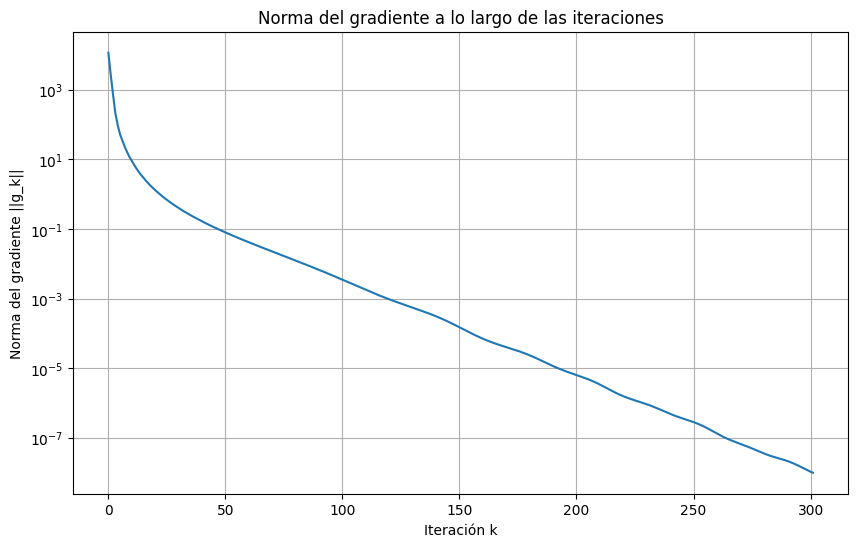

In [6]:
fig = plt.figure(figsize=(10, 6))
plt.plot(k_list, gk_norm_list)
plt.yscale('log')
plt.xlabel('Iteración k')
plt.ylabel('Norma del gradiente ||g_k||')
plt.title('Norma del gradiente a lo largo de las iteraciones')
plt.grid()
plt.show()